# 一般シーン用のストライプ傾き検出

このnotebookは、MF/Iterative MFの2次元alpha画像から、細い高alpha線の傾きを1本、太い帯状offset線の傾きを1本、合計2本の正の傾きを検出します。近い傾きピークは同じ傾き族として統合します。さらに、ハイパースペクトルセンサのline方向とcolumn方向のように直交するノイズ方向も追加し、合計4方向としてCSV/JSON/図に保存します。

0709追記
細い線（卒論でも扱ったもの）についてはQA Imageの傾きと一致していると考えられる

傾きは修士輪講会で扱った手法

## 1. 設定

`ALPHA_PATH` を解析したい2次元alpha画像に変更してください。`.npy`, `.npz`, または `row/y`, `col/x`, `alpha` 系の列を持つCSVに対応しています。全探索なので、大きな画像では時間がかかります。

In [1]:
from pathlib import Path

# 解析したい2D alpha画像。全体画像のalpha_corrected.npyなどに変更してください。
ALPHA_PATH = Path(r"D:/research/code/outputs_paper_sensor_geometry_destripe/baseline_no_destripe_alpha_corrected.npy")

# 出力先
OUTPUT_DIR = Path(r"D:/research/code/outputs_general_scene_slope_detection")

# 必要なら有効画素マスクを指定。不要なら None。
VALID_MASK_PATH = None

# CSV入力の場合だけ、alpha値の列名を明示できます。npyなら None のままでOK。
CSV_VALUE_COLUMN = None

# 正の傾きを角度で全探索します。1-89 degで正の有限傾きをほぼ全域探索します。
ANGLE_MIN_DEG = 10.0
ANGLE_MAX_DEG = 80.0
ANGLE_STEP_DEG = 0.1

# 1.22と1.23のように近い傾きを同じピークとして扱うための分離幅。
MIN_ANGLE_SEPARATION_DEG = 1.0
MIN_SLOPE_SEPARATION = 0.05

# 細い高alpha線の検出設定。1-2 px程度の線を拾うため、thin側は細いbin幅・細かいsampleにします。
THIN_LINE_BIN_WIDTH = 2.0
THIN_SAMPLE_STEP = 1
THIN_HIGH_NSIGMA = 4.0
THIN_LINES_PER_SLOPE = 6
THIN_MIN_HIGH_PIXELS_PER_LINE = 4

# 太い帯状offset線の検出設定。以前の太い線補正と同じ発想なら 18 付近。
BROAD_LINE_BIN_WIDTH = 18.0
BROAD_MIN_PIXELS_PER_LINE = 80

# 計算量調整。大きいほど速いが粗い。全体画像では 4-8 程度から始めるのがおすすめです。
BROAD_SAMPLE_STEP = 4

# 線ごとの代表値。前と同じく median を標準にしています。
STATISTIC_METHOD = "median"

# 高alpha線そのものを検出したい場合は False。実プルームが強すぎる場合は True を試します。
EXCLUDE_HIGH_ALPHA_FROM_OFFSET_ESTIMATE = False

# 右肩上がりの背景トレンドではなく、局所的に突出したピークだけを選ぶ設定。
SELECT_LOCAL_PEAKS_ONLY = True
PEAK_TREND_WINDOW_DEG = 8.0
PEAK_LOCAL_WINDOW_DEG = 1.0
PEAK_EDGE_EXCLUSION_DEG = 1.0
PEAK_MIN_PROMINENCE = None

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ALPHA_PATH, OUTPUT_DIR

(WindowsPath('D:/research/code/outputs_paper_sensor_geometry_destripe/baseline_no_destripe_alpha_corrected.npy'),
 WindowsPath('D:/research/code/outputs_general_scene_slope_detection'))

## 2. スクリプトを読み込む

In [2]:
import importlib.util
import sys

script_candidates = [
    Path.cwd() / "detect_general_scene_stripe_slopes.py",
    Path.cwd() / "outputs" / "detect_general_scene_stripe_slopes.py",
    Path(r"C:/Users/yudon/Documents/Codex/2026-06-05/files-mentioned-by-the-user-improved/outputs/detect_general_scene_stripe_slopes.py"),
]
SCRIPT_PATH = next((p for p in script_candidates if p.exists()), None)
if SCRIPT_PATH is None:
    raise FileNotFoundError("detect_general_scene_stripe_slopes.py が見つかりません。")

spec = importlib.util.spec_from_file_location("general_slope_detector", SCRIPT_PATH)
detector = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = detector
spec.loader.exec_module(detector)

print(SCRIPT_PATH)

d:\research\code\detect_general_scene_stripe_slopes.py


## 3. 傾き検出を実行

細い線のスコアは、各傾き `a` について `b = row - a * col` で線グループを作り、高alpha画素が少数の線グループにどれだけ集中するかで評価します。太い線のスコアは、線ごとのalphaオフセットを仮に引いたときにrobust stdがどれだけ下がるかで評価します。

In [3]:
cfg = detector.SlopeDetectionConfig(
    alpha_path=ALPHA_PATH,
    output_dir=OUTPUT_DIR,
    valid_mask_path=VALID_MASK_PATH,
    csv_value_column=CSV_VALUE_COLUMN,
    angle_min_deg=ANGLE_MIN_DEG,
    angle_max_deg=ANGLE_MAX_DEG,
    angle_step_deg=ANGLE_STEP_DEG,
    thin_top_k=1,
    broad_top_k=1,
    top_k_primary=2,
    min_angle_separation_deg=MIN_ANGLE_SEPARATION_DEG,
    min_slope_separation=MIN_SLOPE_SEPARATION,
    line_bin_width=BROAD_LINE_BIN_WIDTH,
    min_pixels_per_line=BROAD_MIN_PIXELS_PER_LINE,
    sample_step=BROAD_SAMPLE_STEP,
    thin_line_bin_width=THIN_LINE_BIN_WIDTH,
    thin_sample_step=THIN_SAMPLE_STEP,
    thin_high_nsigma=THIN_HIGH_NSIGMA,
    thin_lines_per_slope=THIN_LINES_PER_SLOPE,
    thin_min_high_pixels_per_line=THIN_MIN_HIGH_PIXELS_PER_LINE,
    broad_line_bin_width=BROAD_LINE_BIN_WIDTH,
    broad_min_pixels_per_line=BROAD_MIN_PIXELS_PER_LINE,
    broad_sample_step=BROAD_SAMPLE_STEP,
    statistic_method=STATISTIC_METHOD,
    exclude_high_alpha_from_offset_estimate=EXCLUDE_HIGH_ALPHA_FROM_OFFSET_ESTIMATE,
    select_local_peaks_only=SELECT_LOCAL_PEAKS_ONLY,
    peak_trend_window_deg=PEAK_TREND_WINDOW_DEG,
    peak_local_window_deg=PEAK_LOCAL_WINDOW_DEG,
    peak_edge_exclusion_deg=PEAK_EDGE_EXCLUSION_DEG,
    peak_min_prominence=PEAK_MIN_PROMINENCE,
    verbose=True,
)

result = detector.run_detection(cfg)

Loaded alpha image: shape=(1894, 1761), valid_pixels=1562216
Thin search 1/701: angle=10.00 deg, slope=0.17633
Thin search 50/701: angle=14.90 deg, slope=0.26608
Thin search 100/701: angle=19.90 deg, slope=0.36199
Thin search 150/701: angle=24.90 deg, slope=0.46418
Thin search 200/701: angle=29.90 deg, slope=0.57503
Thin search 250/701: angle=34.90 deg, slope=0.69761
Thin search 300/701: angle=39.90 deg, slope=0.83613
Thin search 350/701: angle=44.90 deg, slope=0.99652
Thin search 400/701: angle=49.90 deg, slope=1.18754
Thin search 450/701: angle=54.90 deg, slope=1.42286
Thin search 500/701: angle=59.90 deg, slope=1.72509
Thin search 550/701: angle=64.90 deg, slope=2.13477
Thin search 600/701: angle=69.90 deg, slope=2.73263
Thin search 650/701: angle=74.90 deg, slope=3.70616
Thin search 700/701: angle=79.90 deg, slope=5.61397
Thin search 701/701: angle=80.00 deg, slope=5.67128
Broad search 1/701: angle=10.00 deg, slope=0.17633
Broad search 50/701: angle=14.90 deg, slope=0.26608
Broad s

## 4. 検出された正の傾き2本（細い1本 + 太い1本）

In [4]:
selected_primary = result["selected_primary"]
display_cols = ["selected_rank", "detection_type", "slope", "angle_deg", "score"]
extra_cols = [c for c in ["selection_score", "peak_prominence", "is_local_peak", "sum_selected_high_pixels", "top_high_pixels", "before_robust_std", "after_robust_std", "n_lines_scored"] if c in selected_primary.columns]
selected_primary[display_cols + extra_cols]

,selected_rank,detection_type,slope,angle_deg,score,selection_score,peak_prominence,is_local_peak,sum_selected_high_pixels,top_high_pixels,before_robust_std,after_robust_std,n_lines_scored
0,1,thin_high_alpha,0.979272,44.4,19231.532933,18476.638601,18476.638601,True,4541.0,1412.0,NaN,NaN,NaN
1,2,broad_offset,1.257172,51.5,0.001911,0.000814,0.000814,True,NaN,NaN,0.034158,0.032247,101.0


## 5. 直交方向を含む4方向

`primary_positive` は全探索で直接選ばれた正の傾きです。`orthogonal_to_primary` は、それに直交する方向です。既存の補正コードに渡す場合は、`direction_key_for_existing_code` と `slope_parameter_for_existing_code` を使います。

In [5]:
six_directions = result["six_directions"]
six_directions[[
    "family_rank",
    "direction_type",
    "signed_slope",
    "angle_deg_0_180",
    "direction_key_for_existing_code",
    "slope_parameter_for_existing_code",
    "equation_form",
]]

,family_rank,direction_type,signed_slope,angle_deg_0_180,direction_key_for_existing_code,slope_parameter_for_existing_code,equation_form
0,1,primary_positive,0.979272,44.4,y_minus_x,0.979272,row = 0.97927235 * col + b
1,1,orthogonal_to_primary,-1.021166,134.4,y_plus_x,1.021166,row = -1.02116638 * col + b
2,2,primary_positive,1.257172,51.5,y_minus_x,1.257172,row = 1.25717230 * col + b
3,2,orthogonal_to_primary,-0.795436,141.5,y_plus_x,0.795436,row = -0.79543592 * col + b


## 6. 保存された図を表示

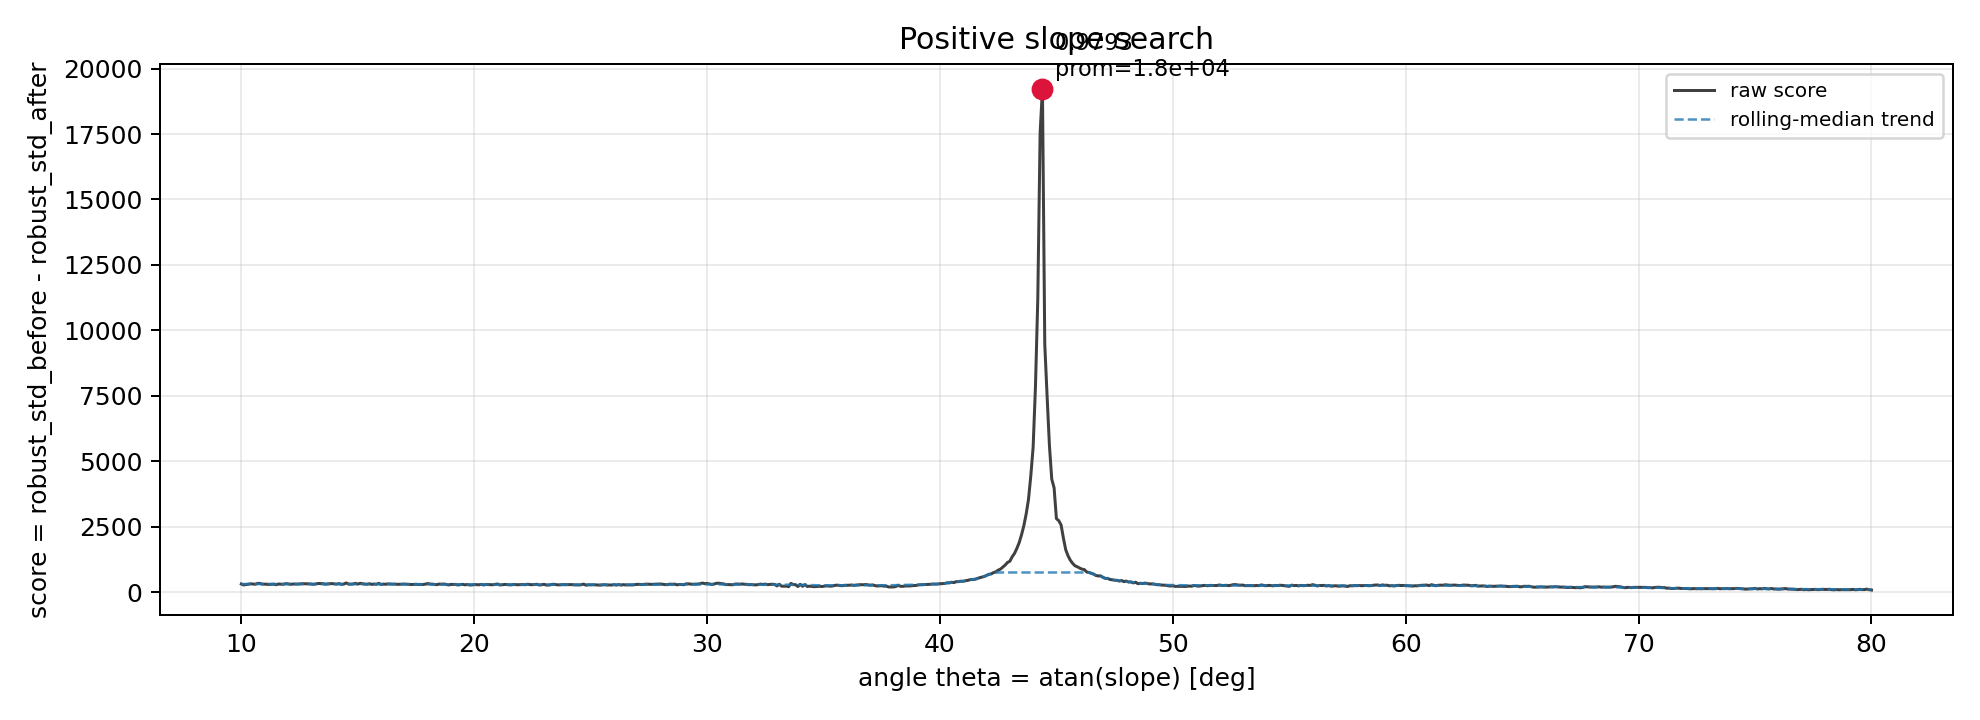

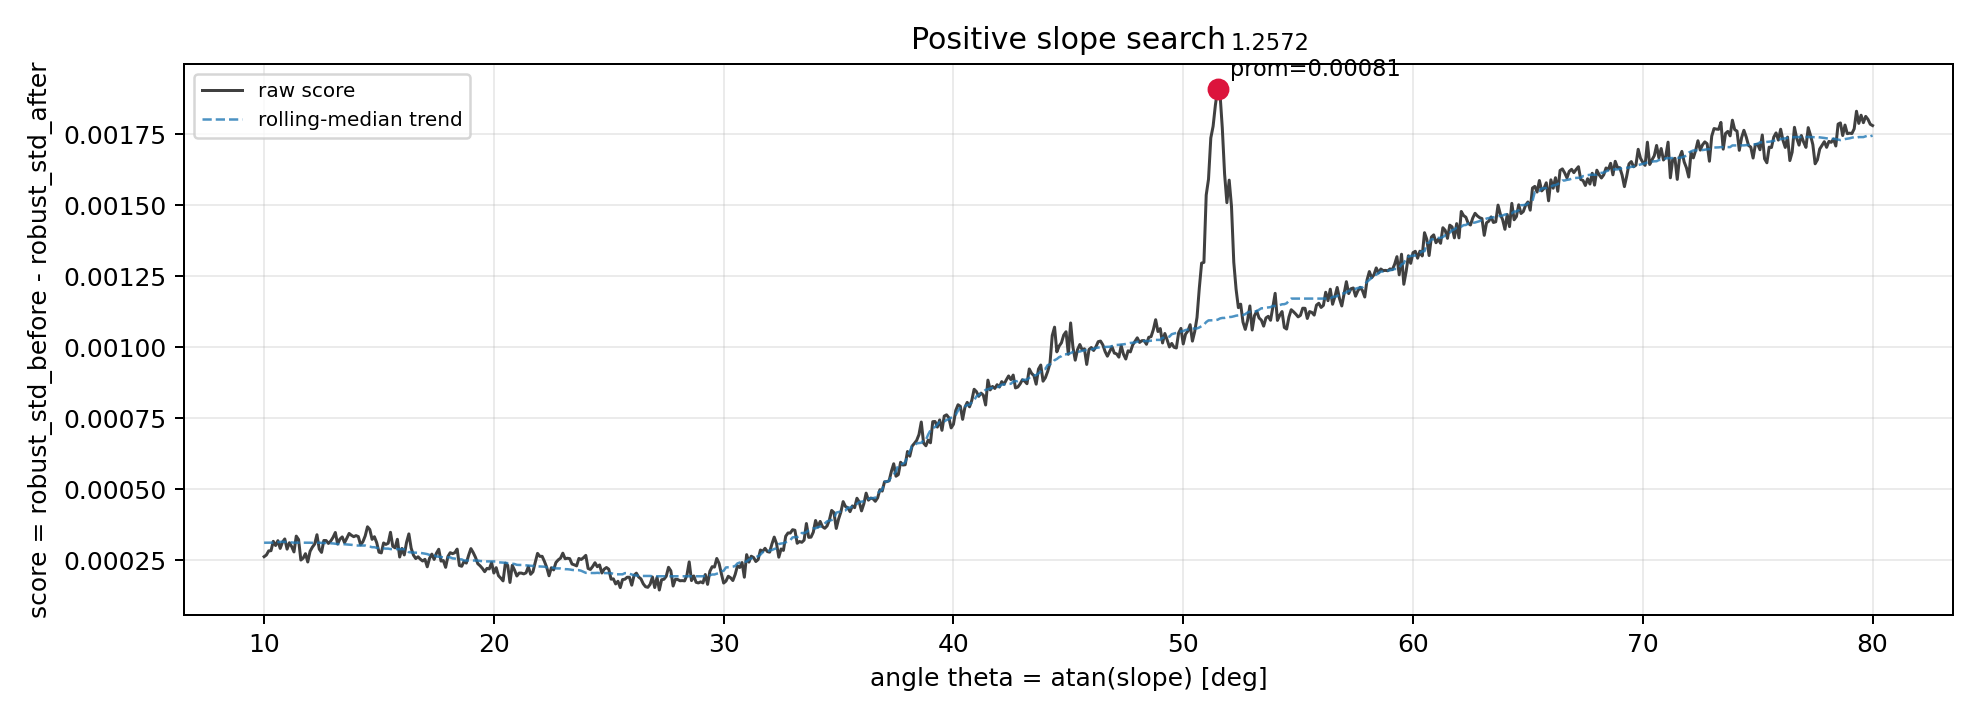

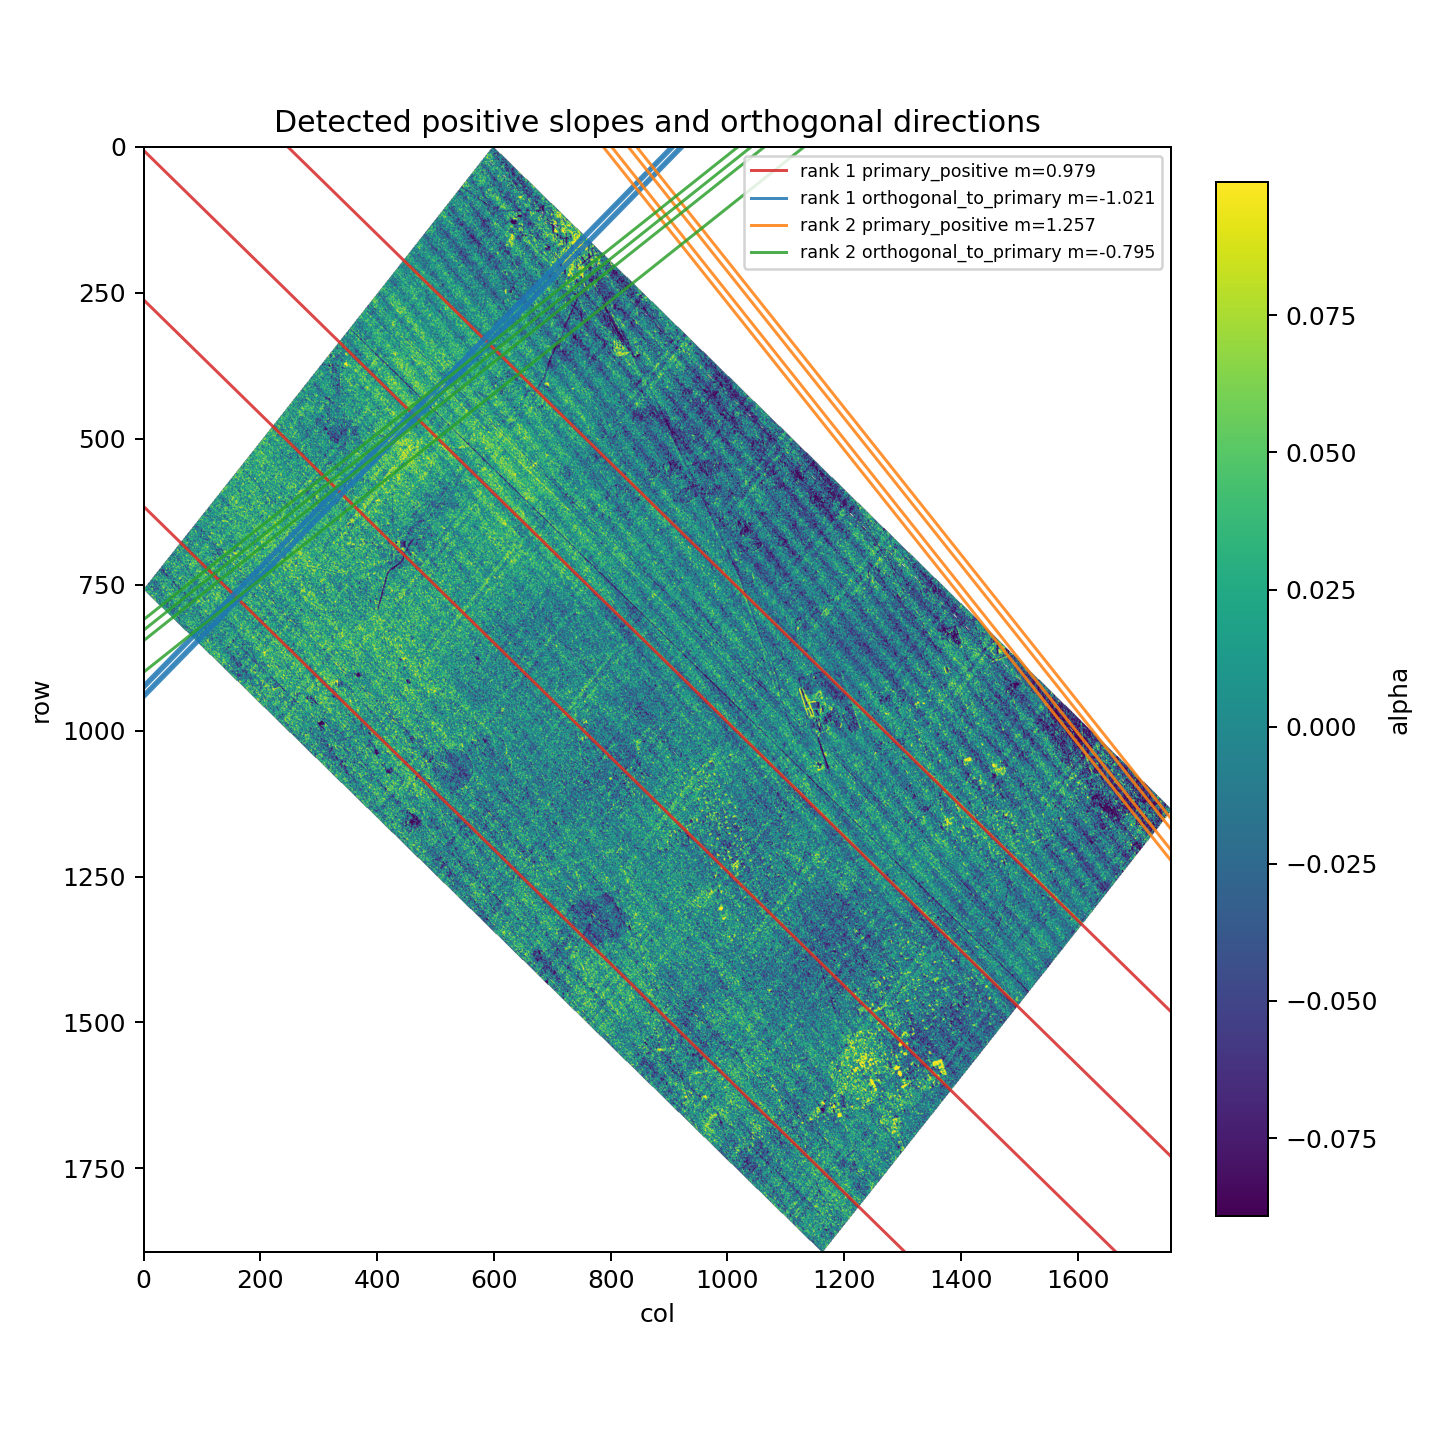

In [6]:
from IPython.display import Image, display

thin_curve = OUTPUT_DIR / "thin_slope_score_curve.png"
broad_curve = OUTPUT_DIR / "broad_slope_score_curve.png"
overlay = OUTPUT_DIR / "detected_slope_overlay.png"
if not overlay.exists():
    overlay = OUTPUT_DIR / "detected_six_slope_overlay.png"

if thin_curve.exists():
    display(Image(filename=str(thin_curve)))
if broad_curve.exists():
    display(Image(filename=str(broad_curve)))
if overlay.exists():
    display(Image(filename=str(overlay)))

## 7. 出力ファイル

- `thin_slope_search_all_candidates.csv`: 細い高alpha線用の正の傾き全候補スコア
- `thin_slope_search_selected.csv`: 細い高alpha線として選んだ1本
- `broad_slope_search_all_candidates.csv`: 太い帯状offset用の正の傾き全候補スコア
- `broad_slope_search_selected.csv`: 太い帯状offsetとして選んだ1本
- `positive_slope_search_all_candidates.csv`: thin/broad両方をまとめた全候補
- `positive_slope_search_selected_primary.csv`: 細い1本 + 太い1本の合計2本
- `detected_slope_directions.csv`: 直交方向を含む4方向
- `detected_slope_directions.json`: 同じ情報のJSON
- `detected_six_slope_directions.csv/json`: 古いコードとの互換用。現在は4方向が入ります
- `detected_overlay_lines.csv`: 図に重ねた代表線の切片
- `thin_slope_score_curve.png`: 細い高alpha線用の傾き探索スコア曲線
- `broad_slope_score_curve.png`: 太い帯状offset用の傾き探索スコア曲線
- `detected_slope_overlay.png`: alpha画像への検出方向オーバーレイ
- `detected_six_slope_overlay.png`: 古いコードとの互換用コピー
- `slope_detection_config.json`: 実行設定

## 8. 直交方向にもノイズが出る理由

プッシュブルーム型のハイパースペクトルセンサでは、画像は概念的にセンサの走査方向と検出器配列方向の2軸で作られます。ある時刻に取得された1ラインに由来する誤差は、地図投影後の画像上で1つの線方向に伸びます。一方で、特定の検出器列、波長方向の補正残差、列ごとの感度差のような誤差は、それとは独立なもう一方のセンサ軸に沿って現れやすくなります。

つまり、片方は「同じ観測時刻・scan lineを共有する画素群」、もう片方は「同じ検出器・columnを共有する画素群」に対応します。元のセンサ座標ではline方向とcolumn方向はほぼ直交しているため、地図投影後の画像座標でも片方の傾きが分かると、その直交方向にも系統誤差が残る可能性があります。このため、正の傾きとして強く検出された方向だけでなく、その直交方向も候補として保存しています。